# Tasks 6 & 7: Feature Selection and Predictive Model

This notebook defines the features for predicting total piece travel time, trains a Gradient Boosting Regressor, and evaluates its performance.

### The prediction problem

**Goal**: Predict the total travel time to the quench bath (`lifetime_bath_s`) using only data available **early in the process** — before the piece has finished the line.

**Why this is useful**: If we can predict the total time after only the 2nd strike, we can raise real-time alerts for pieces that are likely to be slow, allowing operators to investigate the cause while the piece is still on the line.

### Feature selection rationale

**Constraint**: the model must predict using only information available **after the 2nd strike** — approximately 18 seconds into the ~58-second journey. Any feature that requires waiting for later stages cannot be used, because by the time those values exist, the prediction is no longer useful.

#### Selected features

| Feature | Type | Available at | Why include it |
|---|---|---|---|
| `die_matrix` | Categorical (int) | Before processing | Each die has different tooling geometry and expected times — matrix 4974 has a median bath time of ~56s while 5091 has ~59s |
| `lifetime_2nd_strike_s` | Continuous (seconds) | After 2nd strike (~18s) | The earliest cumulative time — if the piece is already slow here, it will likely carry that delay through to the bath |
| `oee_cycle_time_s` | Continuous (seconds) | Rolling metric | Production rate context — slower OEE may correlate with systematic delays (robot trajectory adjustments, hydraulic pressure drops) |

#### Excluded features

| Feature | Why excluded |
|---|---|
| `lifetime_3rd_strike_s` | Available too late (~25s) — the piece is already halfway through the main press |
| `lifetime_4th_strike_s` | Available too late (~38s) — and has ~16% missing data from a sensor offline period |
| `lifetime_auxiliary_press_s` | Available too late (~55s) — only ~2s before the bath, prediction would be useless |
| `lifetime_general_s` | Equivalent to `lifetime_bath_s` — redundant with the target |
| `partial_*` columns | Derived from cumulative times that include late-stage data |
| `piece_id` | Not predictive — just an identifier |

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime, timezone

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
import joblib

pd.set_option('display.float_format', '{:.4f}'.format)
RANDOM_SEED = 42

print(f"Using: sklearn GradientBoostingRegressor")
print(f"Random seed: {RANDOM_SEED}")

Using: sklearn GradientBoostingRegressor
Random seed: 42


## 1. Load gold dataset

In [2]:
gold_path = Path('data/gold/pieces.parquet')
assert gold_path.exists(), "Gold file not found — run 02_silver_to_gold.ipynb first"

df = pd.read_parquet(gold_path)
print(f"Loaded {len(df):,} rows from gold dataset")
print(f"Columns: {list(df.columns)}")
df.head(3)

Loaded 169,154 rows from gold dataset
Columns: ['timestamp', 'piece_id', 'die_matrix', 'lifetime_2nd_strike_s', 'lifetime_3rd_strike_s', 'lifetime_4th_strike_s', 'lifetime_auxiliary_press_s', 'lifetime_bath_s', 'lifetime_general_s', 'oee_cycle_time_s', 'partial_furnace_to_2nd_strike_s', 'partial_2nd_to_3rd_strike_s', 'partial_3rd_to_4th_strike_s', 'partial_4th_strike_to_auxiliary_press_s', 'partial_auxiliary_press_to_bath_s', 'after_gap', 'production_run_id']


,timestamp,piece_id,die_matrix,lifetime_2nd_strike_s,lifetime_3rd_strike_s,lifetime_4th_strike_s,lifetime_auxiliary_press_s,lifetime_bath_s,lifetime_general_s,oee_cycle_time_s,partial_furnace_to_2nd_strike_s,partial_2nd_to_3rd_strike_s,partial_3rd_to_4th_strike_s,partial_4th_strike_to_auxiliary_press_s,partial_auxiliary_press_to_bath_s,after_gap,production_run_id
0,2025-11-06 15:25:16.426000+00:00,251106001721,5052,17.9000,24.6000,38.0000,54.6000,56.2000,56.2000,NaN,17.9000,6.7000,13.4000,16.6000,1.6000,True,1
1,2025-11-06 15:25:29.134000+00:00,251106001722,5052,17.9000,24.6000,37.9000,54.8000,56.4000,56.4000,NaN,17.9000,6.7000,13.3000,16.9000,1.6000,False,1
2,2025-11-06 15:25:43.743000+00:00,251106001723,5052,18.2000,24.8000,38.3000,55.3000,56.9000,56.9000,NaN,18.2000,6.6000,13.5000,17.0000,1.6000,False,1


## 2. Prepare features and target

- **Features (X)**: `die_matrix`, `lifetime_2nd_strike_s`, `oee_cycle_time_s`
- **Target (y)**: `lifetime_bath_s`

Drop rows where any feature or the target is NULL (missing drill data does not affect us here since we don't use drill as a feature).

In [3]:
FEATURES = ['die_matrix', 'lifetime_2nd_strike_s', 'oee_cycle_time_s']
TARGET = 'lifetime_bath_s'

df_model = df[FEATURES + [TARGET]].dropna().copy()
df_model['die_matrix'] = df_model['die_matrix'].astype(int)

print(f"Rows before dropna: {len(df):,}")
print(f"Rows after dropna:  {len(df_model):,}")
print(f"Dropped (NULL OEE or target): {len(df) - len(df_model):,}")
print()
print("Feature summary:")
display(df_model[FEATURES].describe().round(3))
print(f"\nTarget ({TARGET}) summary:")
display(df_model[[TARGET]].describe().round(3))

Rows before dropna: 169,154
Rows after dropna:  129,950
Dropped (NULL OEE or target): 39,204

Feature summary:


,die_matrix,lifetime_2nd_strike_s,oee_cycle_time_s
count,129950.0000,129950.0000,129950.0000
mean,5073.7810,18.5840,13.8780
std,35.9640,2.1770,0.5830
min,4974.0000,9.8000,11.0020
25%,5090.0000,16.9000,13.4700
50%,5090.0000,18.0000,13.8100
75%,5091.0000,19.8000,14.2090
max,5091.0000,31.0000,16.0000



Target (lifetime_bath_s) summary:


,lifetime_bath_s
count,129950.0000
mean,58.4050
std,2.8910
min,44.0000
25%,56.3000
50%,58.1000
75%,60.0000
max,74.2000


## 3. Feature correlation with target

How strongly does each feature correlate with the total bath time? High correlation suggests predictive value.

Pearson correlation with target (lifetime_bath_s):


,pearson_r
die_matrix,0.2274
lifetime_2nd_strike_s,0.8179
oee_cycle_time_s,0.4539


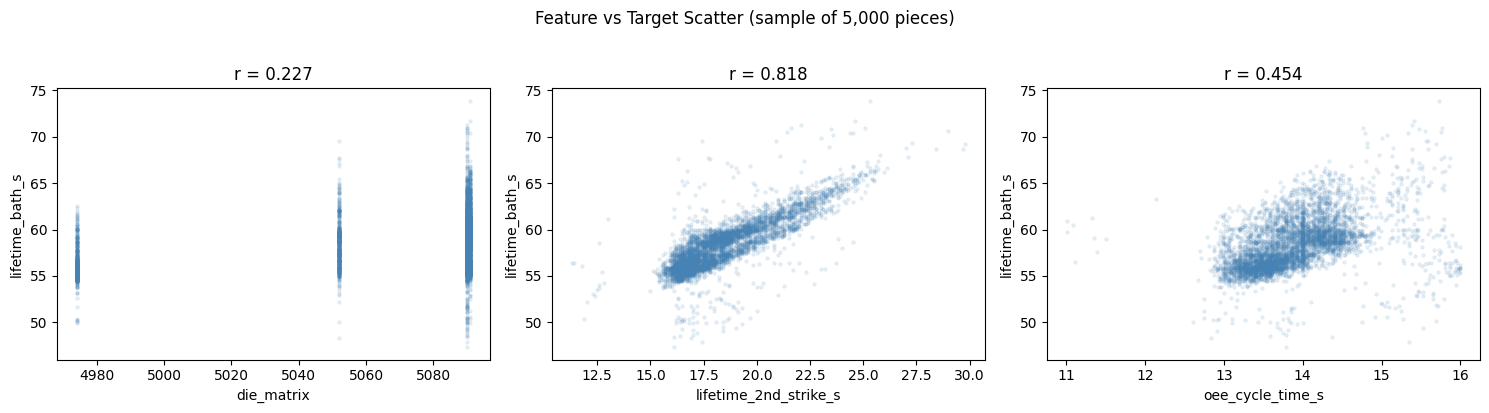

In [4]:
correlations = df_model[FEATURES + [TARGET]].corr(method='pearson')[TARGET].drop(TARGET)
print("Pearson correlation with target (lifetime_bath_s):")
display(correlations.to_frame('pearson_r').round(4))

fig, axes = plt.subplots(1, len(FEATURES), figsize=(15, 4))
for ax, feat in zip(axes, FEATURES):
    sample = df_model.sample(min(5000, len(df_model)), random_state=RANDOM_SEED)
    ax.scatter(sample[feat], sample[TARGET], alpha=0.1, s=5, color='steelblue')
    ax.set_xlabel(feat)
    ax.set_ylabel(TARGET)
    r = correlations[feat]
    ax.set_title(f'r = {r:.3f}')

plt.suptitle('Feature vs Target Scatter (sample of 5,000 pieces)', y=1.02)
plt.tight_layout()
plt.show()

## 4. Train/test split

Split 80/20 with a fixed random seed for reproducibility. Stratify by die_matrix to ensure each matrix is represented proportionally in both sets.

In [5]:
X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=df_model['die_matrix']
)

print(f"Training set:  {len(X_train):,} rows ({100*len(X_train)/len(X):.0f}%)")
print(f"Test set:      {len(X_test):,} rows ({100*len(X_test)/len(X):.0f}%)")
print()
print("Die matrix distribution in training set:")
print(X_train['die_matrix'].value_counts().sort_index().to_string())
print("\nDie matrix distribution in test set:")
print(X_test['die_matrix'].value_counts().sort_index().to_string())

Training set:  103,960 rows (80%)
Test set:      25,990 rows (20%)

Die matrix distribution in training set:
die_matrix
4974    10671
5052    12596
5090    50352
5091    30341

Die matrix distribution in test set:
die_matrix
4974     2668
5052     3149
5090    12588
5091     7585


## 5. Train Gradient Boosting Regressor

Gradient Boosting is chosen because:
- Handles mixed feature types (categorical die_matrix + continuous times)
- Robust to the remaining noise in the data
- Fast training on ~100k rows
- Produces feature importance rankings
- No external runtime dependencies (unlike XGBoost which requires OpenMP)

In [6]:
model = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    min_samples_leaf=10,
    random_state=RANDOM_SEED
)

print("Training model...")
model.fit(X_train, y_train)
print("Model trained successfully")
print(f"\nParameters: n_estimators=300, max_depth=5, learning_rate=0.05, subsample=0.8")

Training model...
Model trained successfully

Parameters: n_estimators=300, max_depth=5, learning_rate=0.05, subsample=0.8


## 6. Evaluate on test set

Key metrics:
- **RMSE**: root mean squared error (same unit as target — seconds)
- **MAE**: mean absolute error (average prediction error in seconds)
- **R²**: coefficient of determination (1.0 = perfect, 0.0 = no better than mean)

TEST SET PERFORMANCE
RMSE:  1.332 s
MAE:   0.653 s
R²:    0.7852

Context: median bath time is ~58s
MAE of 0.65s = 1.1% of median bath time


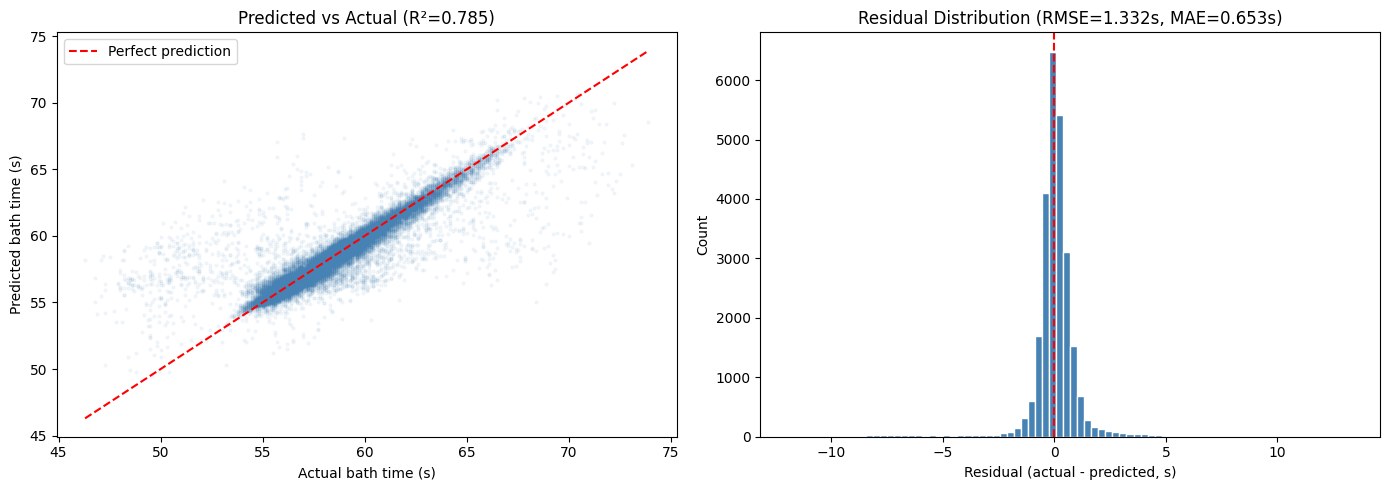

In [7]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("=" * 45)
print("TEST SET PERFORMANCE")
print("=" * 45)
print(f"RMSE:  {rmse:.3f} s")
print(f"MAE:   {mae:.3f} s")
print(f"R²:    {r2:.4f}")
print("=" * 45)
print(f"\nContext: median bath time is ~58s")
print(f"MAE of {mae:.2f}s = {100*mae/y_test.median():.1f}% of median bath time")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.05, s=5, color='steelblue')
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual bath time (s)')
axes[0].set_ylabel('Predicted bath time (s)')
axes[0].set_title(f'Predicted vs Actual (R²={r2:.3f})')
axes[0].legend()

residuals = y_test.values - y_pred
axes[1].hist(residuals, bins=80, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual (actual - predicted, s)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Residual Distribution (RMSE={rmse:.3f}s, MAE={mae:.3f}s)')

plt.tight_layout()
plt.show()

## 7. Performance per die matrix

Check if the model performs equally well across all matrices, or if some are harder to predict.

Performance per die matrix:


,n_test,RMSE,MAE,R2
die_matrix,,,,
4974,2668,0.7810,0.4130,0.7986
5052,3149,1.0910,0.4820,0.8149
5090,12588,1.5860,0.8390,0.7024
5091,7585,1.0930,0.5000,0.8596


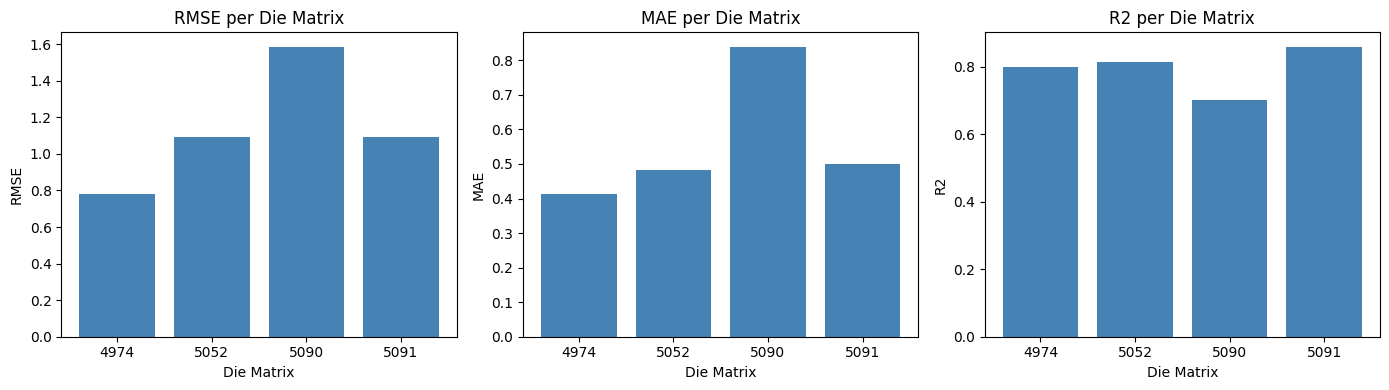

In [8]:
results = []
test_df = X_test.copy()
test_df['y_true'] = y_test.values
test_df['y_pred'] = y_pred

for matrix in sorted(test_df['die_matrix'].unique()):
    grp = test_df[test_df['die_matrix'] == matrix]
    rmse_m = np.sqrt(mean_squared_error(grp['y_true'], grp['y_pred']))
    mae_m  = mean_absolute_error(grp['y_true'], grp['y_pred'])
    r2_m   = r2_score(grp['y_true'], grp['y_pred'])
    results.append({
        'die_matrix': int(matrix),
        'n_test': len(grp),
        'RMSE': round(rmse_m, 3),
        'MAE':  round(mae_m, 3),
        'R2':   round(r2_m, 4)
    })

df_results = pd.DataFrame(results).set_index('die_matrix')
print("Performance per die matrix:")
display(df_results)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ['RMSE', 'MAE', 'R2']):
    ax.bar([str(m) for m in df_results.index], df_results[metric], color='steelblue')
    ax.set_xlabel('Die Matrix')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} per Die Matrix')
plt.tight_layout()
plt.show()

## 8. Feature importance

Which features contribute most to the prediction? This validates the feature selection rationale.

Feature importance (gain):


,importance
lifetime_2nd_strike_s,0.7868
oee_cycle_time_s,0.1995
die_matrix,0.0136


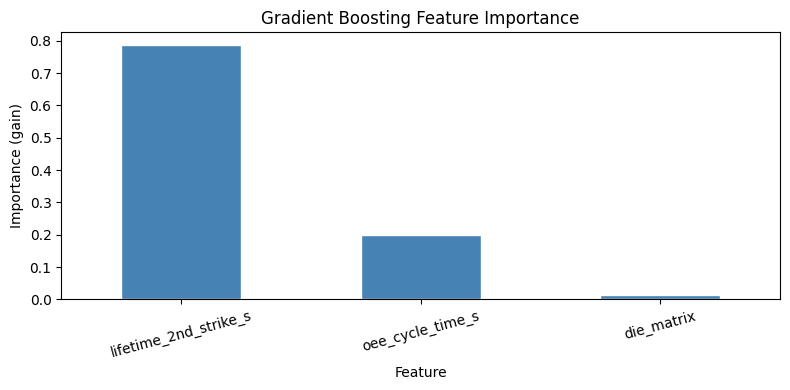

In [9]:
importance = pd.Series(
    model.feature_importances_,
    index=FEATURES
).sort_values(ascending=False)

print("Feature importance (gain):")
display(importance.to_frame('importance').round(4))

fig, ax = plt.subplots(figsize=(8, 4))
importance.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Feature')
ax.set_ylabel('Importance (gain)')
ax.set_title('Gradient Boosting Feature Importance')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

## 9. Save model and metadata

Save the trained model and its metadata for use by the inference service (Task 8).

In [10]:
models_dir = Path('models')
models_dir.mkdir(exist_ok=True)

# Save model using joblib
model_path = models_dir / 'xgboost_bath_predictor.joblib'
joblib.dump(model, model_path)
print(f"Model saved to: {model_path}")

# Save metadata
metadata = {
    'model_type': 'GradientBoostingRegressor',
    'target': TARGET,
    'features': FEATURES,
    'hyperparameters': {
        'n_estimators': 300,
        'max_depth': 5,
        'learning_rate': 0.05,
        'subsample': 0.8,
        'min_samples_leaf': 10,
        'random_state': RANDOM_SEED
    },
    'training': {
        'n_train': len(X_train),
        'n_test': len(X_test),
        'train_ratio': 0.80,
        'stratified_by': 'die_matrix',
        'trained_at': datetime.now(timezone.utc).isoformat()
    },
    'metrics': {
        'rmse': round(rmse, 4),
        'mae': round(mae, 4),
        'r2': round(r2, 4)
    },
    'per_matrix_metrics': df_results.reset_index().to_dict(orient='records')
}

metadata_path = models_dir / 'model_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Metadata saved to: {metadata_path}")
print(json.dumps(metadata, indent=2))

Model saved to: models/xgboost_bath_predictor.joblib
Metadata saved to: models/model_metadata.json
{
  "model_type": "GradientBoostingRegressor",
  "target": "lifetime_bath_s",
  "features": [
    "die_matrix",
    "lifetime_2nd_strike_s",
    "oee_cycle_time_s"
  ],
  "hyperparameters": {
    "n_estimators": 300,
    "max_depth": 5,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "min_samples_leaf": 10,
    "random_state": 42
  },
  "training": {
    "n_train": 103960,
    "n_test": 25990,
    "train_ratio": 0.8,
    "stratified_by": "die_matrix",
    "trained_at": "2026-04-03T21:25:48.301588+00:00"
  },
  "metrics": {
    "rmse": 1.3318,
    "mae": 0.6529,
    "r2": 0.7852
  },
  "per_matrix_metrics": [
    {
      "die_matrix": 4974,
      "n_test": 2668,
      "RMSE": 0.781,
      "MAE": 0.413,
      "R2": 0.7986
    },
    {
      "die_matrix": 5052,
      "n_test": 3149,
      "RMSE": 1.091,
      "MAE": 0.482,
      "R2": 0.8149
    },
    {
      "die_matrix": 5090,
      

## 10. Summary

In [11]:
print("=" * 55)
print("MODEL SUMMARY")
print("=" * 55)
print(f"Model:       Gradient Boosting Regressor (sklearn)")
print(f"Target:      {TARGET} (total piece travel time)")
print(f"Features:    {FEATURES}")
print(f"Constraint:  Only data available after 2nd strike (~18s)")
print()
print(f"Training set: {len(X_train):,} pieces")
print(f"Test set:     {len(X_test):,} pieces")
print()
print(f"RMSE:  {rmse:.3f} s  ({100*rmse/y_test.median():.1f}% of median bath time)")
print(f"MAE:   {mae:.3f} s  ({100*mae/y_test.median():.1f}% of median bath time)")
print(f"R²:    {r2:.4f}")
print()
print(f"Model saved: {model_path}")
print(f"Metadata:    {metadata_path}")
print("=" * 55)
print()
print("Interpretation:")
print(f"  On average, the model predicts bath time to within {mae:.2f}s")
print(f"  on a ~58s journey, using only data from the first ~18s.")
print(f"  R²={r2:.3f} means the model explains {100*r2:.1f}% of bath time variance.")

MODEL SUMMARY
Model:       Gradient Boosting Regressor (sklearn)
Target:      lifetime_bath_s (total piece travel time)
Features:    ['die_matrix', 'lifetime_2nd_strike_s', 'oee_cycle_time_s']
Constraint:  Only data available after 2nd strike (~18s)

Training set: 103,960 pieces
Test set:     25,990 pieces

RMSE:  1.332 s  (2.3% of median bath time)
MAE:   0.653 s  (1.1% of median bath time)
R²:    0.7852

Model saved: models/xgboost_bath_predictor.joblib
Metadata:    models/model_metadata.json

Interpretation:
  On average, the model predicts bath time to within 0.65s
  on a ~58s journey, using only data from the first ~18s.
  R²=0.785 means the model explains 78.5% of bath time variance.
